# TP4 - Validation et Cohérence des Données

**Difficulté:** Intermédiaire  
**Dataset:** healthcare_inconsistent.csv  
**Description:** Vérification des contraintes logiques et cohérence inter-colonnes

---


## Imports des Bibliothèques


In [3]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Ignorer les warnings
import warnings
warnings.filterwarnings('ignore')

# Affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Bibliothèques importées avec succès!")

 Bibliothèques importées avec succès!


## Import du Dataset


In [4]:
# Charger le dataset
df = pd.read_csv('../data/healthcare_inconsistent.csv')

# Afficher les informations de base
print(f"📏 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f" Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*80 + "\n")

# Aperçu des données
display(df.head())
print("\n" + "="*80 + "\n")

# Informations sur les colonnes
df.info()

📏 Dimensions: 300 lignes × 9 colonnes
 Taille mémoire: 0.08 MB




,patient_id,age,birth_date,email,start_date,end_date,price,postal_code,heart_rate
0,1,42,1920-01-01,wlmit@company.com,2023-01-01,2023-01-05,601.91,3340,35
1,2,24,1920-01-02,invalid-email,2023-01-02,2023-01-06,-95.26,2120,132
2,3,17,1920-01-03,wkimx@company.com,2023-01-03,2023-01-07,4506.44,9691,39
3,4,-5,1920-01-04,krvzm@gmail.com,2023-01-04,2023-01-08,25.55,1138,100
4,5,12,1920-01-05,dzicv@gmail.com,2023-01-05,2023-01-09,968.22,3688,119




<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   patient_id   300 non-null    int64  
 1   age          300 non-null    int64  
 2   birth_date   300 non-null    str    
 3   email        300 non-null    str    
 4   start_date   300 non-null    str    
 5   end_date     300 non-null    str    
 6   price        300 non-null    float64
 7   postal_code  300 non-null    int64  
 8   heart_rate   300 non-null    int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 21.2 KB


## Visualisation des Valeurs Manquantes


<Figure size 1400x800 with 0 Axes>

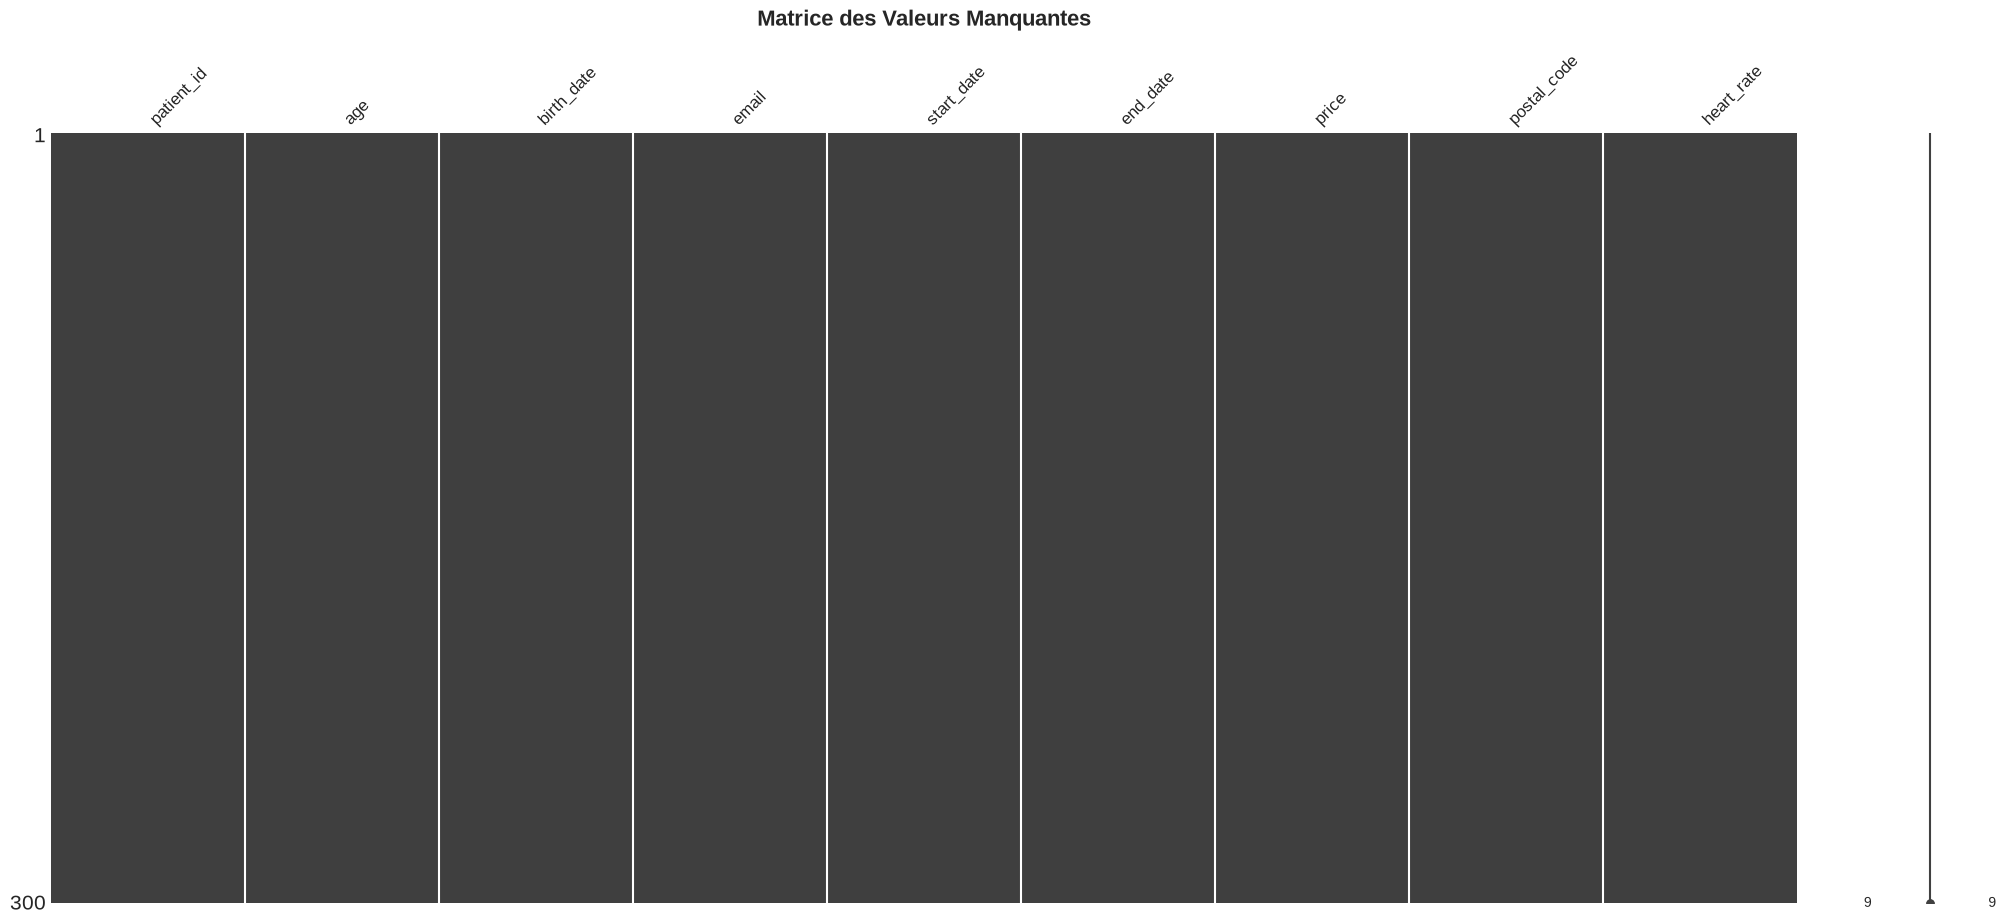


📊 Statistiques des Valeurs Manquantes:



,Nombre_Missing,Pourcentage_Missing


In [5]:
# Matrice de visualisation des valeurs manquantes
plt.figure(figsize=(14, 8))
msno.matrix(df, fontsize=12, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Statistiques des valeurs manquantes
missing_stats = pd.DataFrame({
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage_Missing', ascending=False)

print("\n📊 Statistiques des Valeurs Manquantes:\n")
display(missing_stats[missing_stats['Nombre_Missing'] > 0])


## Questions Préalables

**Avant de commencer le TP, répondez aux questions suivantes en analysant le dataset:**

1. Y a-t-il des âges négatifs ou supérieurs à 120 ans ?
2. Les dates de fin sont-elles toujours après les dates de début ?
3. Y a-t-il des emails sans '@' ?
4. Les codes postaux respectent-ils le format attendu ?
5. Y a-t-il des incohérences entre l'âge et la date de naissance ?
6. Les prix sont-ils tous positifs ?
7. Y a-t-il des valeurs aberrantes dans les signes vitaux ?
8. Les unités de mesure sont-elles cohérentes ?
9. Combien d'enregistrements violent au moins une contrainte ?
10. Quelle contrainte est la plus souvent violée ?


In [17]:
#1. Y a-t-il des âges négatifs ou supérieurs à 120 ans ?
print(df.age.min())
print(df.age.max())

-5
118


In [28]:
#2. Les dates de fin sont-elles toujours après les dates de début ?
(df.start_date < df.end_date).value_counts()


True     295
False      5
Name: count, dtype: int64

In [47]:
#3. Y a-t-il des emails sans '@' ?
len(df) - df.email.str.contains("@").sum()

np.int64(8)

In [40]:
#4. Les codes postaux respectent-ils le format attendu ?
df.postal_code

0      3340
1      2120
2      9691
3      1138
4      3688
       ... 
295    9128
296    1483
297    7270
298    7990
299    3831
Name: postal_code, Length: 300, dtype: int64

In [41]:
#5. Y a-t-il des incohérences entre l'âge et la date de naissance ?
df

,patient_id,age,birth_date,email,start_date,end_date,price,postal_code,heart_rate
0,1,42,1920-01-01,wlmit@company.com,2023-01-01,2023-01-05,601.91,3340,35
1,2,24,1920-01-02,invalid-email,2023-01-02,2023-01-06,-95.26,2120,132
2,3,17,1920-01-03,wkimx@company.com,2023-01-03,2023-01-07,4506.44,9691,39
3,4,-5,1920-01-04,krvzm@gmail.com,2023-01-04,2023-01-08,25.55,1138,100
4,5,12,1920-01-05,dzicv@gmail.com,2023-01-05,2023-01-09,968.22,3688,119
...,...,...,...,...,...,...,...,...,...
295,296,66,1920-10-22,rqbqs@yahoo.com,2023-10-23,2023-10-27,3452.46,9128,224
296,297,111,1920-10-23,lccfc@yahoo.com,2023-10-24,2023-10-28,4612.77,1483,219
297,298,62,1920-10-24,nlaid@company.com,2023-10-25,2023-10-29,4083.65,7270,144
298,299,109,1920-10-25,smfcu@gmail.com,2023-10-26,2023-10-30,2765.51,7990,30


In [ ]:
#6. Les prix sont-ils tous positifs ?


In [ ]:
#7. Y a-t-il des valeurs aberrantes dans les signes vitaux ?


In [ ]:
#8. Les unités de mesure sont-elles cohérentes ?


In [ ]:

#9. Combien d'enregistrements violent au moins une contrainte ?


In [ ]:
#10. Quelle contrainte est la plus souvent violée ?

In [ ]:
#  Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions

# Exemple d'analyses:
# df.describe()
# df['colonne'].value_counts()
# df.isnull().sum()
# etc.

print("Réponses aux questions:")
print("="*80)

# Écrivez vos réponses ici


## Étapes du TP

**Suivez les étapes ci-dessous pour nettoyer le dataset:**

### Étape 1: Définir un dictionnaire de contraintes de validation
### Étape 2: Créer une fonction validate_constraints(df)
### Étape 3: Valider les plages numériques (âge, prix, etc.)
### Étape 4: Valider les formats (email, téléphone, code postal)
### Étape 5: Vérifier la cohérence inter-colonnes (dates, âge/date_naissance)
### Étape 6: Créer des indicateurs pour chaque violation
### Étape 7: Décider des actions correctives pour chaque type
### Étape 8: Appliquer les corrections
### Étape 9: Standardiser les unités de mesure
### Étape 10: Générer un rapport de validation complet


In [ ]:
# ========================================
# Étape 1: Définir un dictionnaire de contraintes de validation
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 1 complétée")

In [ ]:
# ========================================
# Étape 2: Créer une fonction validate_constraints(df)
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 2 complétée")

In [ ]:
# ========================================
# Étape 3: Valider les plages numériques (âge, prix, etc.)
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 3 complétée")

In [ ]:
# ========================================
# Étape 4: Valider les formats (email, téléphone, code postal)
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 4 complétée")

In [ ]:
# ========================================
# Étape 5: Vérifier la cohérence inter-colonnes (dates, âge/date_naissance)
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 5 complétée")

In [ ]:
# ========================================
# Étape 6: Créer des indicateurs pour chaque violation
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 6 complétée")

In [ ]:
# ========================================
# Étape 7: Décider des actions correctives pour chaque type
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 7 complétée")

In [ ]:
# ========================================
# Étape 8: Appliquer les corrections
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 8 complétée")

In [ ]:
# ========================================
# Étape 9: Standardiser les unités de mesure
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 9 complétée")

In [ ]:
# ========================================
# Étape 10: Générer un rapport de validation complet
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 10 complétée")

## Rapport Final

**Créez un rapport résumant toutes les transformations effectuées**


In [ ]:
# Rapport de nettoyage
rapport = {
    'Dimensions_initiales': df.shape,
    'Dimensions_finales': df.shape,  # À mettre à jour avec df_clean
    'Lignes_supprimées': 0,
    'Colonnes_supprimées': 0,
    'Valeurs_manquantes_traitées': 0,
    'Doublons_supprimés': 0,
    'Outliers_traités': 0,
    'Transformations_appliquées': []
}

print("=" * 80)
print(" " * 25 + " RAPPORT DE NETTOYAGE")
print("=" * 80)

for key, value in rapport.items():
    print(f"{key:.<40} {value}")

print("=" * 80)
print("\n TP terminé avec succès!")